## **Customer Segmentation using K Means Clustering(RFM Based)**

**Segment customers based on purchasing behavior using RFM and K-Means clustering to support targeted marketing and retention strategies.**

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df=pd.read_excel('/content/online_retail_II.xlsx', sheet_name=0)

In [3]:
df_raw=df.copy()
len(df_raw)

525461

**Exploratory Analysis**

In [4]:
df.shape

(525461, 8)

In [5]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [8]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [9]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [10]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [11]:
df['Invoice'] = df['Invoice'].astype('str')
df[df['Invoice'].str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [12]:
df[df['Invoice'].str.startswith('C')]['Invoice'].count()

np.int64(10206)

In [13]:
cleaned_df = df.copy()

In [14]:
cleaned_df["StockCode"]=cleaned_df["StockCode"].astype("str")

filter =((cleaned_df["StockCode"].str.match("^\\d{5}$")== True) | (cleaned_df["StockCode"].str.match("^\\d{5}$[a-zA-Z]+$")== True) )

cleaned_df=cleaned_df[filter]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [15]:
cleaned_df.dropna(subset=["Customer ID"], inplace =True)

In [16]:
cleaned_df[cleaned_df['Price']>0.0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [17]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,358793.000000,358793,358793.000000,358793.000000
mean,12.917069,2010-07-05 09:25:16.174395648,3.019263,15352.592687
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-31 13:32:00,1.250000,13979.000000
50%,5.000000,2010-07-18 11:36:00,1.950000,15311.000000
75%,12.000000,2010-10-17 13:40:00,3.750000,16794.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,104.288474,NaN,4.628008,1679.478675


In [18]:
len(cleaned_df)

358793

In [19]:
cleaned_df['Sales']= cleaned_df ['Price']*cleaned_df['Quantity']

**Feature Engineering (RFM)**

In [20]:
aggregated_df= cleaned_df.groupby("Customer ID").agg(
    MonetaryValue = ('Sales',"sum"),
    Frequency = ('Invoice', "nunique"),
    LastInvoiceDate = ('InvoiceDate',"max")
)

In [21]:
aggregated_df.head(5)

,MonetaryValue,Frequency,LastInvoiceDate
Customer ID,,,
12346.0,144.02,2,2010-06-28 13:53:00
12347.0,966.87,2,2010-12-07 14:57:00
12348.0,221.16,1,2010-09-27 14:59:00
12349.0,1922.49,3,2010-10-28 08:23:00
12351.0,300.93,1,2010-11-29 15:23:00


In [22]:
max_invoice_date = aggregated_df['LastInvoiceDate'].max()

aggregated_df['Recency']= (max_invoice_date - aggregated_df['LastInvoiceDate']).dt.days

aggregated_df

,MonetaryValue,Frequency,LastInvoiceDate,Recency
Customer ID,,,,
12346.0,144.02,2,2010-06-28 13:53:00,164
12347.0,966.87,2,2010-12-07 14:57:00,2
12348.0,221.16,1,2010-09-27 14:59:00,73
12349.0,1922.49,3,2010-10-28 08:23:00,42
12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...
18283.0,563.19,6,2010-11-22 15:30:00,17
18284.0,391.28,1,2010-10-04 11:33:00,66
18285.0,361.10,1,2010-02-17 10:24:00,295


**Monetary, Frequency, Recency Distribution**

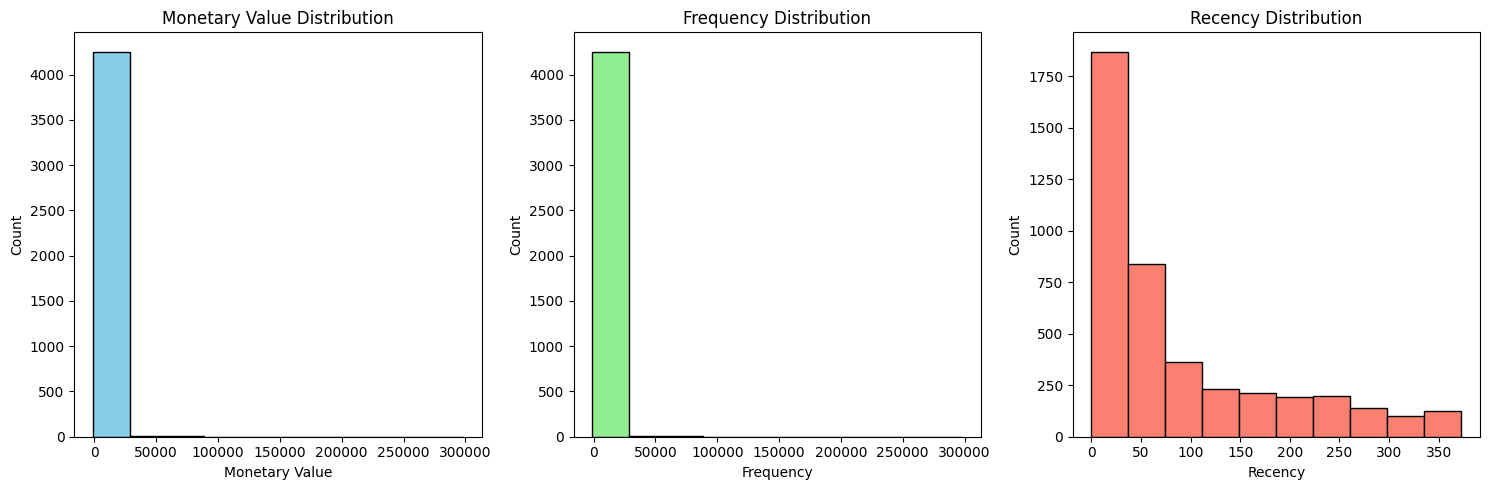

In [23]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.hist(aggregated_df['Recency'], bins=10, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Outlier Handling**

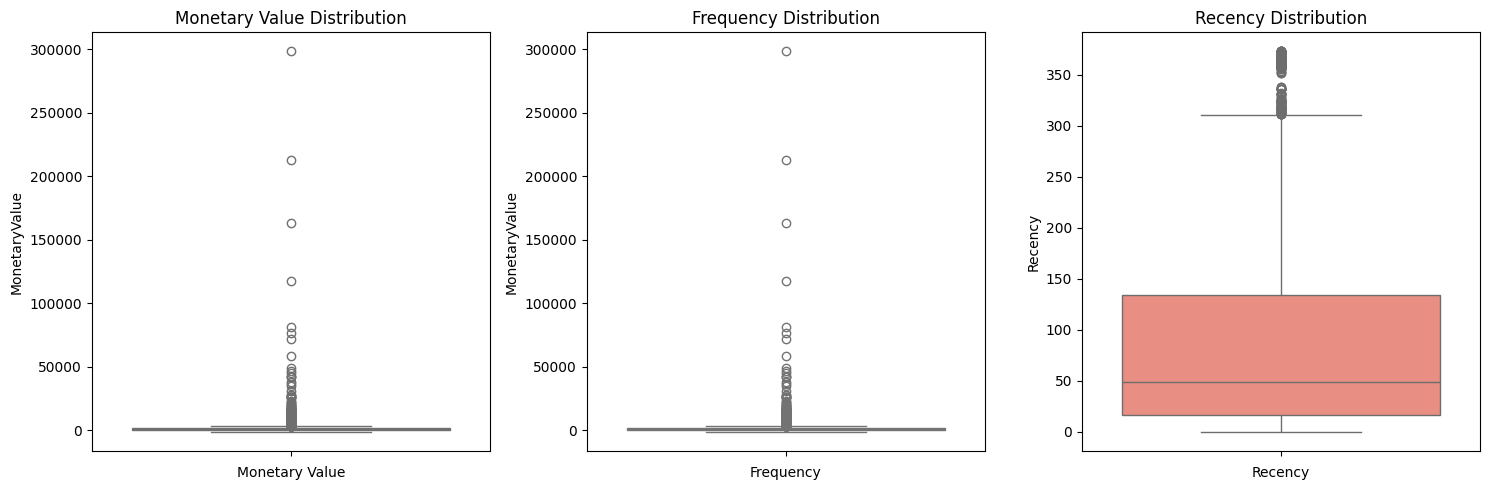

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')


plt.subplot(1,3,2)
sns.boxplot(aggregated_df['MonetaryValue'], color='lightgreen')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')


plt.subplot(1,3,3)
sns.boxplot(aggregated_df['Recency'],color='salmon')
plt.title('Recency Distribution')
plt.xlabel('Recency')


plt.tight_layout()
plt.show()

In [25]:
M_Q1= aggregated_df['MonetaryValue'].quantile(0.25)

M_Q3 = aggregated_df['MonetaryValue'].quantile(0.5)

M_IQR = M_Q3 - M_Q1

monetary_outliers_df =aggregated_df[(aggregated_df['MonetaryValue']>(M_Q3+1.5*M_IQR)) | (aggregated_df['MonetaryValue']<(M_Q1-1.5*M_IQR))]

monetary_outliers_df.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,1388.000000,1388.000000,1388,1388.000000
mean,4288.210166,11.023055,2010-10-29 05:22:26.195965440,41.337896
min,-1254.360000,1.000000,2009-12-08 14:04:00,0.000000
25%,1470.610000,5.000000,2010-10-15 13:04:15,7.000000
50%,2145.370000,8.000000,2010-11-18 10:53:30,21.000000
75%,3628.462500,12.000000,2010-12-02 10:40:45,55.000000
max,298203.400000,228.000000,2010-12-09 19:32:00,366.000000
std,12512.937009,14.401626,NaN,55.727893


In [26]:
F_Q1= aggregated_df['Frequency'].quantile(0.25)

F_Q3 = aggregated_df['Frequency'].quantile(0.5)

F_IQR = F_Q3 - F_Q1

frequency_outliers_df =aggregated_df[(aggregated_df['Frequency']>(F_Q3+1.5*F_IQR)) | (aggregated_df['Frequency']<(F_Q1-1.5*F_IQR))]

frequency_outliers_df.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,921.000000,921.000000,921,921.000000
mean,5291.590825,15.000000,2010-11-10 21:50:44.625407232,28.651466
min,-83.850000,7.000000,2010-03-10 12:17:00,0.000000
25%,1560.240000,8.000000,2010-11-07 14:26:00,4.000000
50%,2470.090000,11.000000,2010-11-25 14:50:00,14.000000
75%,4333.080000,15.000000,2010-12-05 15:06:00,32.000000
max,298203.400000,228.000000,2010-12-09 19:32:00,274.000000
std,15211.462823,16.346586,NaN,42.130505


In [27]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))]

non_outliers_df.describe()

,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,2783.000000,2783.000000,2783,2783.000000
mean,398.130952,2.163852,2010-08-17 22:00:58.749550848,113.639598
min,-103.200000,1.000000,2009-12-01 12:35:00,0.000000
25%,175.950000,1.000000,2010-06-04 09:51:00,28.000000
50%,326.300000,2.000000,2010-09-30 13:57:00,70.000000
75%,577.195000,3.000000,2010-11-11 12:23:30,188.000000
max,1105.180000,6.000000,2010-12-09 20:01:00,373.000000
std,276.884306,1.366289,NaN,104.786767


**Non - Outlier Distribution**

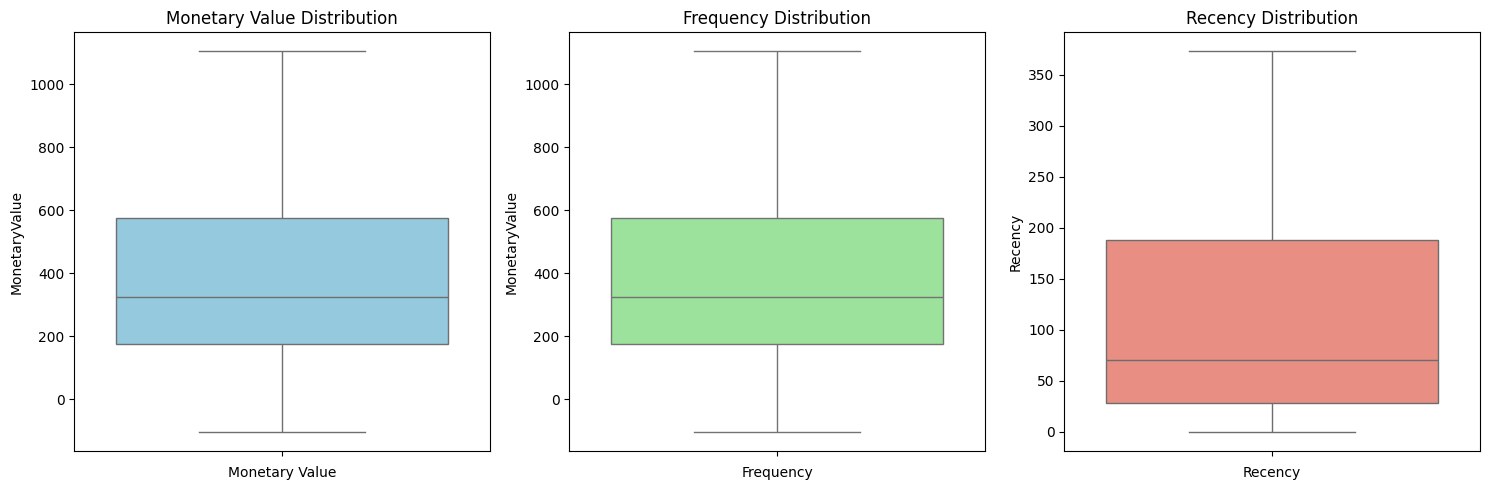

In [28]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')


plt.subplot(1,3,2)
sns.boxplot(non_outliers_df['MonetaryValue'], color='lightgreen')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')


plt.subplot(1,3,3)
sns.boxplot(non_outliers_df['Recency'],color='salmon')
plt.title('Recency Distribution')
plt.xlabel('Recency')


plt.tight_layout()
plt.show()

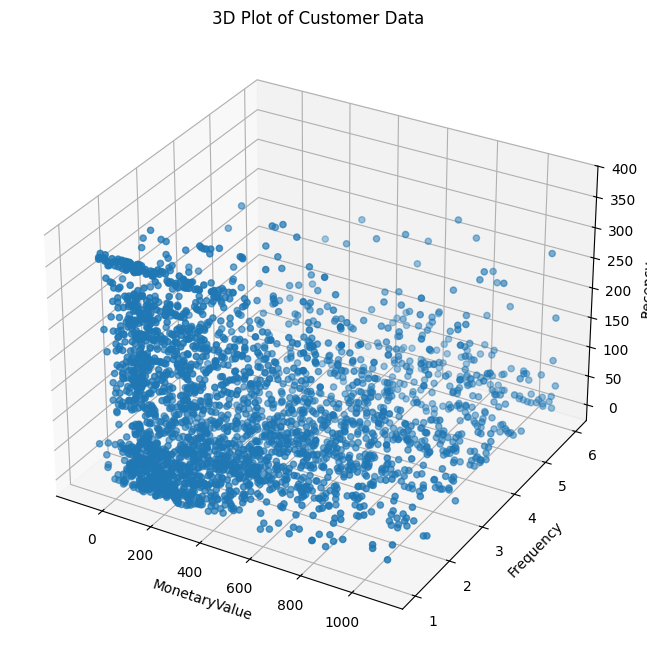

In [29]:
fig =plt.figure(figsize =(8,8))
ax = fig.add_subplot( projection='3d')
scatter = ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Frequency'], non_outliers_df['Recency'])
ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Plot of Customer Data')
plt.show()

**Feature Scaling (Z - Scaling)**

In [30]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue', 'Frequency', 'Recency']])
scaled_data

array([[-0.9179163 , -0.1199464 ,  0.48068524],
       [ 2.05443662, -0.1199464 , -1.06558933],
       [-0.63926612, -0.85198771, -0.38790109],
       ...,
       [-0.02474746, -0.85198771, -0.45471542],
       [-0.13376564, -0.85198771,  1.73106777],
       [ 1.98735684, -0.1199464 , -0.02519471]])

In [31]:
scaled_data_df = pd.DataFrame(scaled_data, columns=['MonetaryValue', 'Frequency', 'Recency'])
scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.917916,-0.119946,0.480685
1,2.054437,-0.119946,-1.065589
2,-0.639266,-0.851988,-0.387901
3,-0.351116,-0.851988,-0.989230
4,-0.237438,-0.119946,-0.989230
...,...,...,...
2778,-1.084803,-0.851988,0.938841
2779,0.596237,2.808219,-0.922416
2780,-0.024747,-0.851988,-0.454715
2781,-0.133766,-0.851988,1.731068


#**KMeans Clustering**


**Elbow Method & Silhouette Score to find optimal Clusters K**

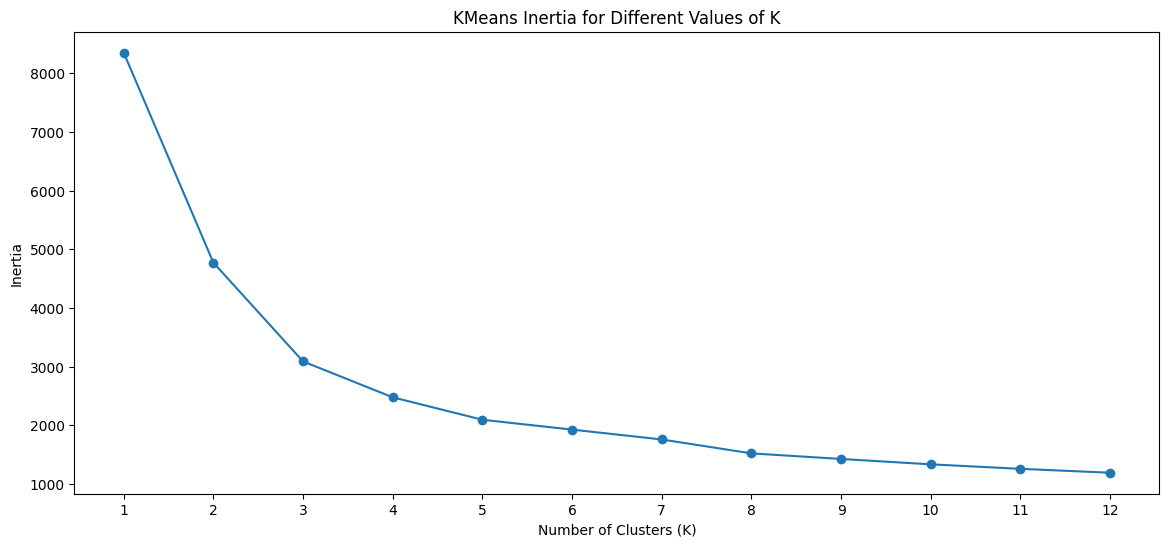

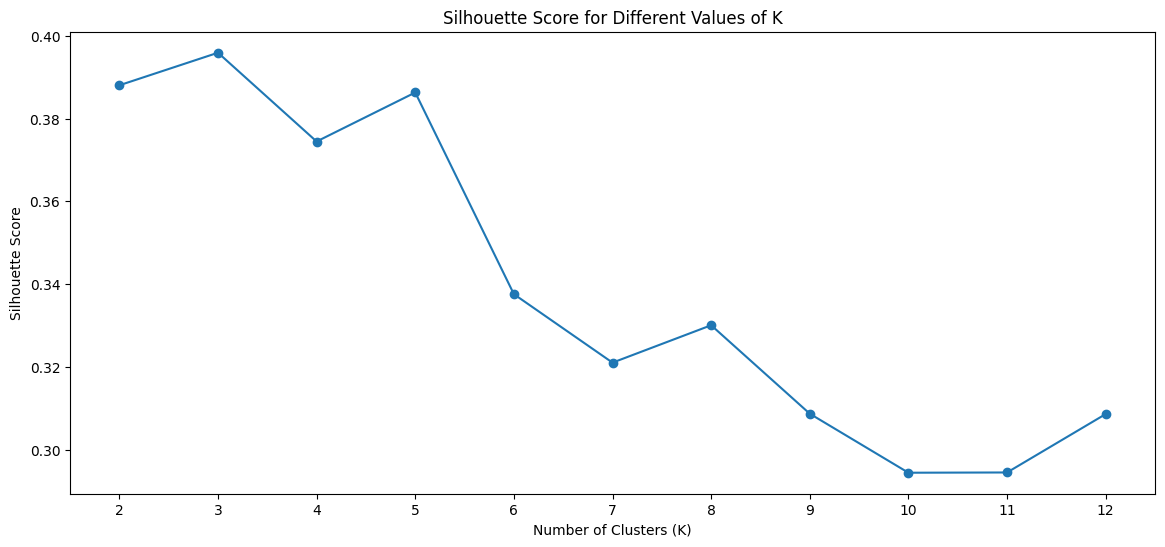

In [36]:
max_k = 12

wcss =[]

k_values= range(1,max_k+1)
k_values_for_silscore = range(2, max_k+1)

silscore=[]

for k in k_values:
  model = KMeans(n_clusters=k,random_state=0, n_init='auto') # Added n_init='auto' for KMeans
  cluster_labels  = model.fit_predict(scaled_data_df)
  wcss.append(model.inertia_)
  if k > 1: # Only calculate silhouette for k > 1
    sil_score = silhouette_score(scaled_data_df, cluster_labels)
    silscore.append(sil_score)

plt.figure(figsize = (14,6))
plt.plot(k_values, wcss, marker='o')
plt.title ('KMeans Inertia for Different Values of K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()


plt.figure(figsize = (14,6))
plt.plot(k_values_for_silscore, silscore, marker='o') # Use k_values_for_silscore for plotting
plt.title ('Silhouette Score for Different Values of K') # Corrected title
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score') # Corrected y-label
plt.xticks(k_values_for_silscore)
plt.show()

In [37]:
kmeans = KMeans(n_clusters=3,random_state=0)
cluster_labels =kmeans.fit_predict(scaled_data_df)
cluster_labels

array([2, 1, 0, ..., 0, 2, 1], dtype=int32)

In [38]:
non_outliers_df['Cluster']=cluster_labels
non_outliers_df

/tmp/ipykernel_1855/98664061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['Cluster']=cluster_labels


,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
Customer ID,,,,,
12346.0,144.02,2,2010-06-28 13:53:00,164,2
12347.0,966.87,2,2010-12-07 14:57:00,2,1
12348.0,221.16,1,2010-09-27 14:59:00,73,0
12351.0,300.93,1,2010-11-29 15:23:00,10,0
12352.0,332.40,2,2010-11-29 10:07:00,10,0
...,...,...,...,...,...
18281.0,97.82,1,2010-05-11 10:49:00,212,2
18283.0,563.19,6,2010-11-22 15:30:00,17,1
18284.0,391.28,1,2010-10-04 11:33:00,66,0


 **Violin Plot : Cluster Distribution**

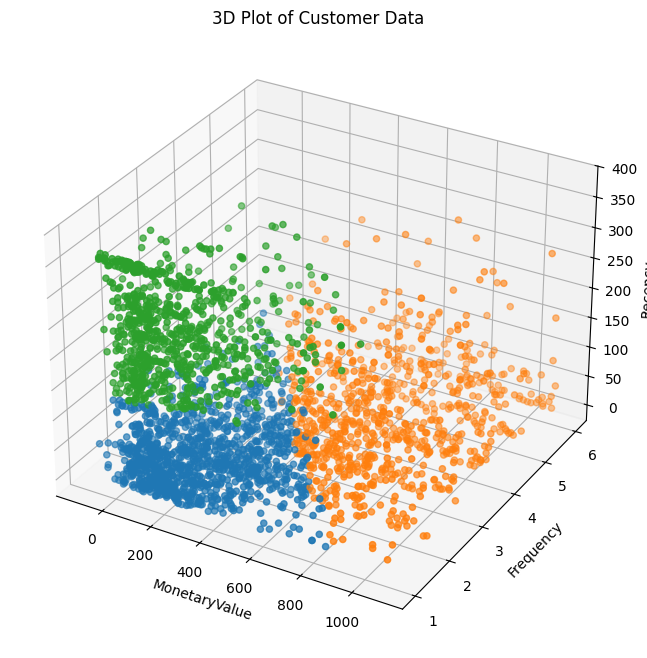

In [43]:
cluster_colors = {0:'#1f77b4',1: '#ff7f0e', 2:'#2ca02c', 3:'#d62728'}

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig =plt.figure(figsize =(8,8))
ax = fig.add_subplot( projection='3d')
scatter = ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Frequency'], non_outliers_df['Recency'],c=colors,marker='o')
ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Plot of Customer Data')
plt.show()

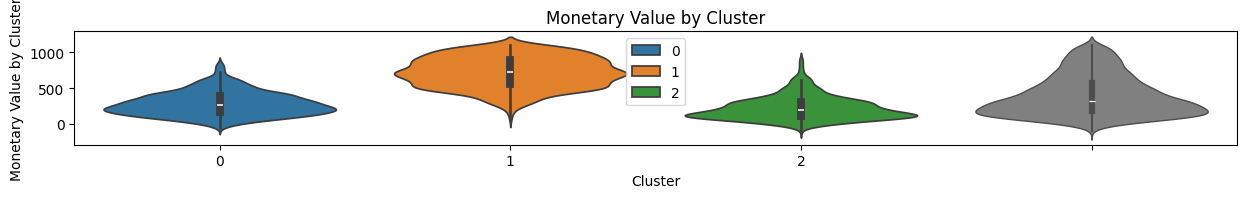

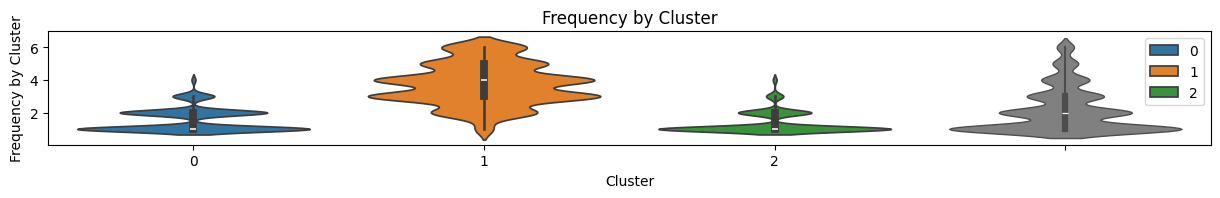

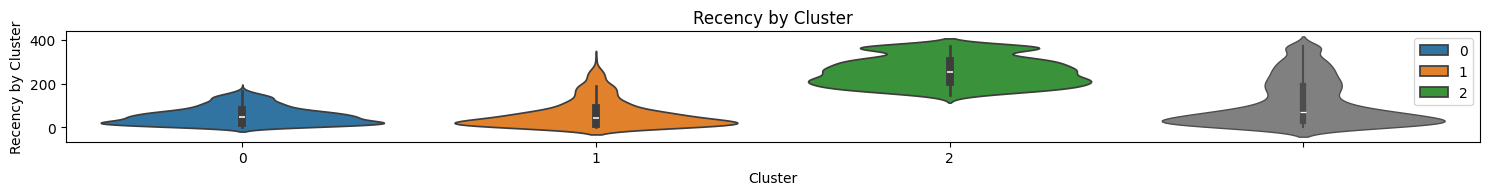

In [42]:
plt.figure(figsize=(15,5))
plt.subplot(3,1,1)
sns.violinplot(x= non_outliers_df['Cluster'],y=non_outliers_df['MonetaryValue'],palette =cluster_colors, hue=non_outliers_df['Cluster'] )
sns.violinplot(y=non_outliers_df['MonetaryValue'],color = 'grey', linewidth =1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value by Cluster')


plt.figure(figsize=(15,5))
plt.subplot(3,1,1)
sns.violinplot(x= non_outliers_df['Cluster'],y=non_outliers_df['Frequency'],palette =cluster_colors, hue=non_outliers_df['Cluster'] )
sns.violinplot(y=non_outliers_df['Frequency'],color = 'grey', linewidth =1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency by Cluster')



plt.figure(figsize=(15,5))
plt.subplot(3,1,1)
sns.violinplot(x= non_outliers_df['Cluster'],y=non_outliers_df['Recency'],palette =cluster_colors, hue=non_outliers_df['Cluster'] )
sns.violinplot(y=non_outliers_df['Recency'],color = 'grey', linewidth =1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency by Cluster')


plt.tight_layout()
plt.show()

**1. Cluster 1 (Orange):**
* These are "Premium Loyal Customers" – they have high monetary value, high
frequency, and low recency (purchased recently)."

**2. Cluster 0 (Blue):**
* These are "Valuable Regular Customers" or "Engaged Customers" – they have moderate monetary value, moderate frequency, and moderate recency. "

**3. Cluster 2 (Green):**
* These are  "At-Risk Customers" or "Churn Candidates" – they have low monetary value, low frequency, and high recency (haven't purchased recently)."






#Cluster Interpretation
**1. Cluster 0 : Blue**

*   Rationale : This cluster represents valuable regular customers who spend
significantly and purchase relatively recently, but not as frequently as Cluster 1.

**2. Cluser 1** : **Yellow**

*   Rationale : This cluster represents premium loyal customers who purchase very recently, very frequently, and contribute the highest spending


**3. Cluster 2 : Green**

*   Rationale : represents at-risk customers with low spending, infrequent
purchases, and long inactivity periods.

**4. Cluster 3 : Red**
*   Rationale : represents moderately engaged customers who purchase relatively recently, spend moderately, but have not yet developed strong purchase frequency.

In [44]:
labels= {0 : 'Engaged Customer',
        1 : 'Premium Loyal Customer',
        2 : 'At-Risk Customers' }


In [45]:
non_outliers_df['ClusterLabel'] = non_outliers_df['Cluster'].map(labels)
non_outliers_df

/tmp/ipykernel_1855/1925118066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['ClusterLabel'] = non_outliers_df['Cluster'].map(labels)


,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
Customer ID,,,,,,
12346.0,144.02,2,2010-06-28 13:53:00,164,2,At-Risk Customers
12347.0,966.87,2,2010-12-07 14:57:00,2,1,Premium Loyal Customer
12348.0,221.16,1,2010-09-27 14:59:00,73,0,Engaged Customer
12351.0,300.93,1,2010-11-29 15:23:00,10,0,Engaged Customer
12352.0,332.40,2,2010-11-29 10:07:00,10,0,Engaged Customer
...,...,...,...,...,...,...
18281.0,97.82,1,2010-05-11 10:49:00,212,2,At-Risk Customers
18283.0,563.19,6,2010-11-22 15:30:00,17,1,Premium Loyal Customer
18284.0,391.28,1,2010-10-04 11:33:00,66,0,Engaged Customer
